In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/heart.csv")

df = df.drop_duplicates()
print(f"Kopyalar temizlendi. Yeni satır sayısı: {df.shape[0]}")

print("--- Veri Setinin İlk 5 Satırı ---")
display(df.head())

print("\n--- Veri Seti Bilgileri ---")
df.info()

print("\n--- İstatistiksel Özet ---")
display(df.describe().T)

Kopyalar temizlendi. Yeni satır sayısı: 302
--- Veri Setinin İlk 5 Satırı ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



--- Veri Seti Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB

--- İstatistiksel Özet ---


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [2]:
print("Kolesterolü (chol) 0 olan kişi sayısı:", (df['chol'] == 0).sum())
print("Kan Basıncı (trestbps) 0 olan kişi sayısı:", (df['trestbps'] == 0).sum())

cols_to_fix = ['chol', 'trestbps']

for col in cols_to_fix:
    if (df[col] == 0).sum() > 0:
        print(f"\nUYARI: {col} sütununda 0 değerleri tespit edildi. Temizleniyor...")
     
        df[col] = df[col].replace(0, np.nan)
        
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        
        print(f"{col} sütunundaki 0 değerleri, medyan değeri ({median_val}) ile dolduruldu.")
    else:
        print(f"{col} sütunu temiz. (0 değeri yok)")

Kolesterolü (chol) 0 olan kişi sayısı: 0
Kan Basıncı (trestbps) 0 olan kişi sayısı: 0
chol sütunu temiz. (0 değeri yok)
trestbps sütunu temiz. (0 değeri yok)


In [3]:
print("Mevcut Sütun İsimleri:")
print(df.columns.tolist())

Mevcut Sütun İsimleri:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


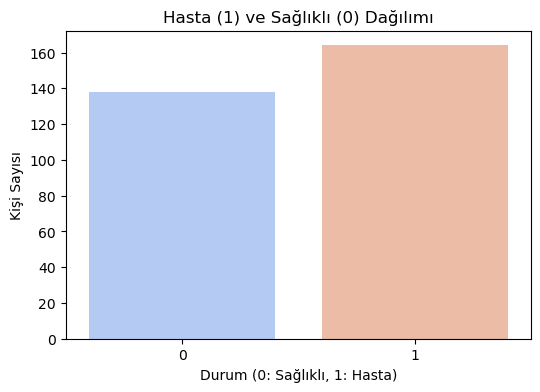

Sınıf Dağılımı:
target
1    164
0    138
Name: count, dtype: int64

Oransal Dağılım:
target
1    0.543046
0    0.456954
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='coolwarm')
plt.title("Hasta (1) ve Sağlıklı (0) Dağılımı")
plt.xlabel("Durum (0: Sağlıklı, 1: Hasta)")
plt.ylabel("Kişi Sayısı")
plt.show()

print("Sınıf Dağılımı:")
print(df['target'].value_counts())
print("\nOransal Dağılım:")
print(df['target'].value_counts(normalize=True))

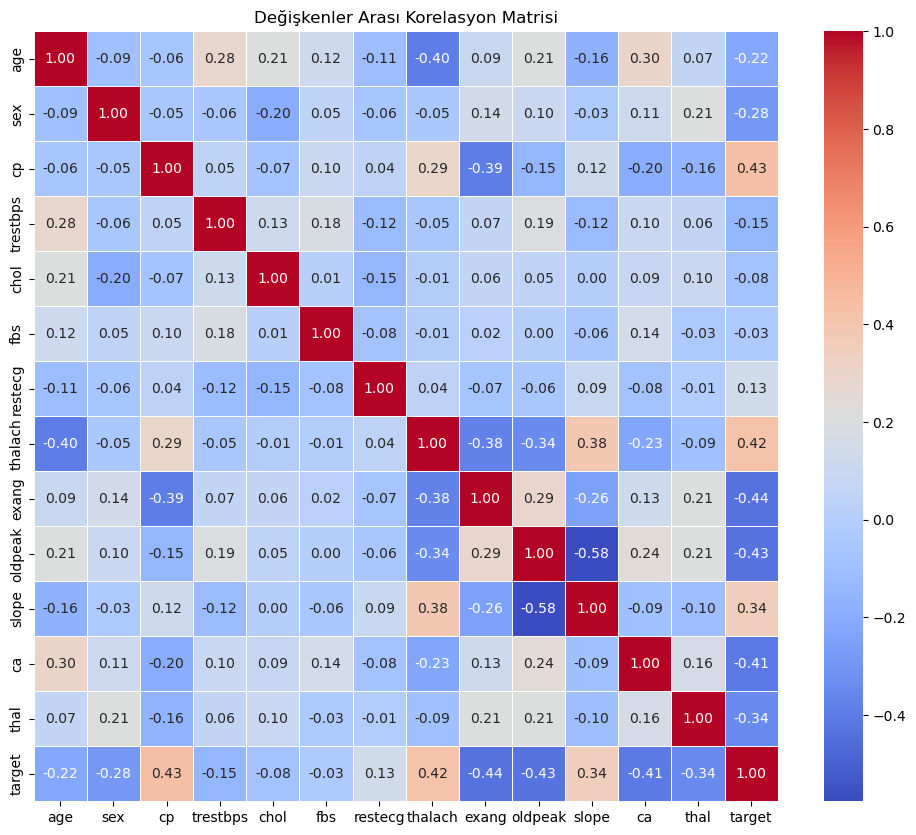

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Değişkenler Arası Korelasyon Matrisi")
plt.show()

In [6]:
categorical_cols = ['cp', 'thal', 'slope']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Encoding İşlemi Tamamlandı.")
print("Yeni Sütun İsimleri:")
print(df.columns.tolist())

display(df.head())

Encoding İşlemi Tamamlandı.
Yeni Sütun İsimleri:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'thal_1', 'thal_2', 'thal_3', 'slope_1', 'slope_2']


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,slope_1,slope_2
0,52,1,125,212,0,1,168,0,1.0,2,0,False,False,False,False,False,True,False,True
1,53,1,140,203,1,0,155,1,3.1,0,0,False,False,False,False,False,True,False,False
2,70,1,145,174,0,1,125,1,2.6,0,0,False,False,False,False,False,True,False,False
3,61,1,148,203,0,1,161,0,0.0,1,0,False,False,False,False,False,True,False,True
4,62,0,138,294,1,1,106,0,1.9,3,0,False,False,False,False,True,False,True,False


In [7]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Ölçeklendirme Tamamlandı. Veriler standartlaştırıldı.")
display(df.head())

Ölçeklendirme Tamamlandı. Veriler standartlaştırıldı.


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,slope_1,slope_2
0,-0.267966,1,-0.376556,-0.667728,0,1,0.806035,0,-0.037124,2,0,False,False,False,False,False,True,False,True
1,-0.157260,1,0.478910,-0.841918,1,0,0.237495,1,1.773958,0,0,False,False,False,False,False,True,False,False
2,1.724733,1,0.764066,-1.403197,0,1,-1.074521,1,1.342748,0,0,False,False,False,False,False,True,False,False
3,0.728383,1,0.935159,-0.841918,0,1,0.499898,0,-0.899544,1,0,False,False,False,False,False,True,False,True
4,0.839089,0,0.364848,0.919336,1,1,-1.905464,0,0.739054,3,0,False,False,False,False,True,False,True,False


In [8]:
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,slope_1,slope_2
0,-0.267966,1,-0.376556,-0.667728,0,1,0.806035,0,-0.037124,2,0,False,False,False,False,False,True,False,True
1,-0.157260,1,0.478910,-0.841918,1,0,0.237495,1,1.773958,0,0,False,False,False,False,False,True,False,False
2,1.724733,1,0.764066,-1.403197,0,1,-1.074521,1,1.342748,0,0,False,False,False,False,False,True,False,False
3,0.728383,1,0.935159,-0.841918,0,1,0.499898,0,-0.899544,1,0,False,False,False,False,False,True,False,True
4,0.839089,0,0.364848,0.919336,1,1,-1.905464,0,0.739054,3,0,False,False,False,False,True,False,True,False


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)

y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Veri Seti Bölündü:")
print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

Veri Seti Bölündü:
Eğitim Seti Boyutu: (241, 18)
Test Seti Boyutu: (61, 18)


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def model_degerlendir(model, X_train, y_train, X_test, y_test, model_adi):
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(f"--- {model_adi} Analizi ---")
    print(f"Eğitim (Train) Skoru: %{train_acc*100:.2f}")
    print(f"Test Skoru:           %{test_acc*100:.2f}")
    
    fark = train_acc - test_acc
    if fark > 0.10: 
        print(f"UYARI: %{fark*100:.1f} fark var! Model Overfitting yapıyor.")
    else:
        print(f"BAŞARILI: Model dengeli. (Fark: %{fark*100:.1f})")
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_adi} Confusion Matrix")
    plt.show()

--- Logistic Regression Analizi ---
Eğitim (Train) Skoru: %87.97
Test Skoru:           %75.41
UYARI: %12.6 fark var! Model Overfitting yapıyor.


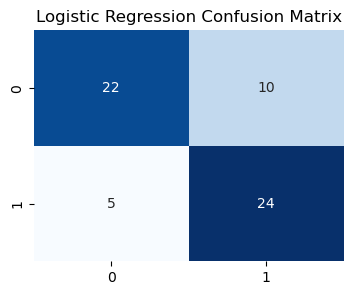

In [11]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

model_degerlendir(log_model, X_train, y_train, X_test, y_test, "Logistic Regression")

--- Random Forest Analizi ---
Eğitim (Train) Skoru: %100.00
Test Skoru:           %78.69
UYARI: %21.3 fark var! Model Overfitting yapıyor.


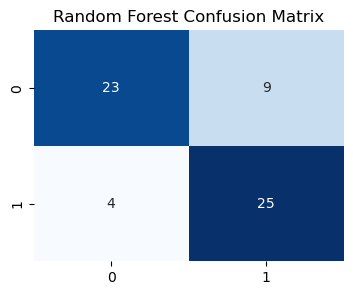

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

model_degerlendir(rf_model, X_train, y_train, X_test, y_test, "Random Forest")

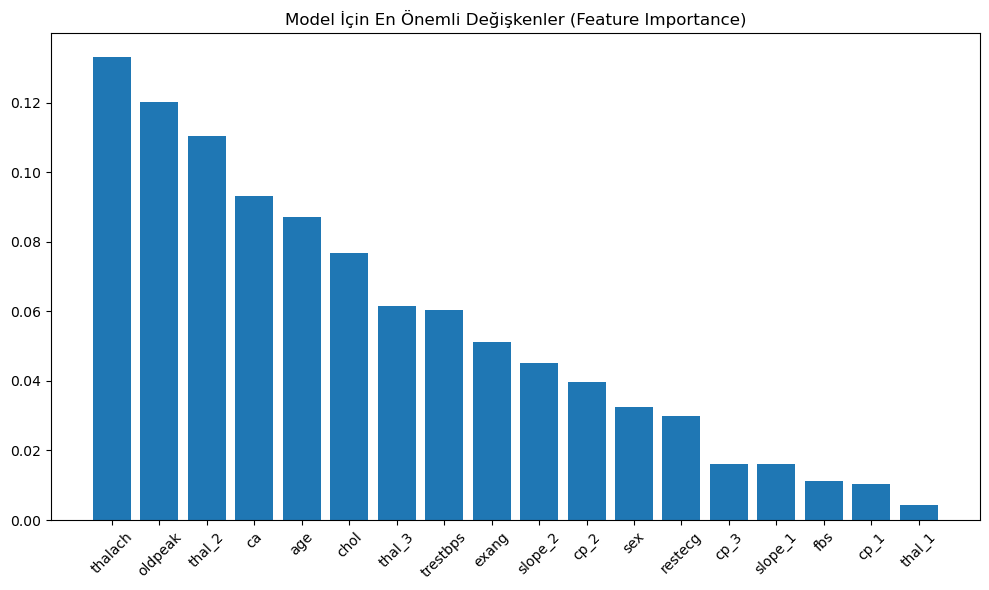

In [13]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 6))
plt.title("Model İçin En Önemli Değişkenler (Feature Importance)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [14]:
!pip install pgmpy networkx

In [15]:
import pandas as pd
from IPython.display import display

df_bayes = pd.read_csv("../data/heart.csv") 

df_bayes['age_cat'] = pd.cut(df_bayes['age'], bins=[0, 40, 60, 100], labels=['Genc', 'Orta', 'Yasli'])

df_bayes['cp_cat'] = df_bayes['cp'].apply(lambda x: 'Tip 0 (Dusuk)' if x == 0 else 'Tip 1+ (Yuksek)')

df_bayes['target_cat'] = df_bayes['target'].map({0: 'Saglikli', 1: 'Hasta'})

print("Özellik Seçimi sonucu en yüksek pozitif ilişki 'cp' (Göğüs Ağrısı) değişkeninde bulundu.")
display(df_bayes[['age_cat', 'cp_cat', 'target_cat']].head())

Özellik Seçimi sonucu en yüksek pozitif ilişki 'cp' (Göğüs Ağrısı) değişkeninde bulundu.


,age_cat,cp_cat,target_cat
0,Orta,Tip 0 (Dusuk),Saglikli
1,Orta,Tip 0 (Dusuk),Saglikli
2,Yasli,Tip 0 (Dusuk),Saglikli
3,Yasli,Tip 0 (Dusuk),Saglikli
4,Yasli,Tip 0 (Dusuk),Saglikli


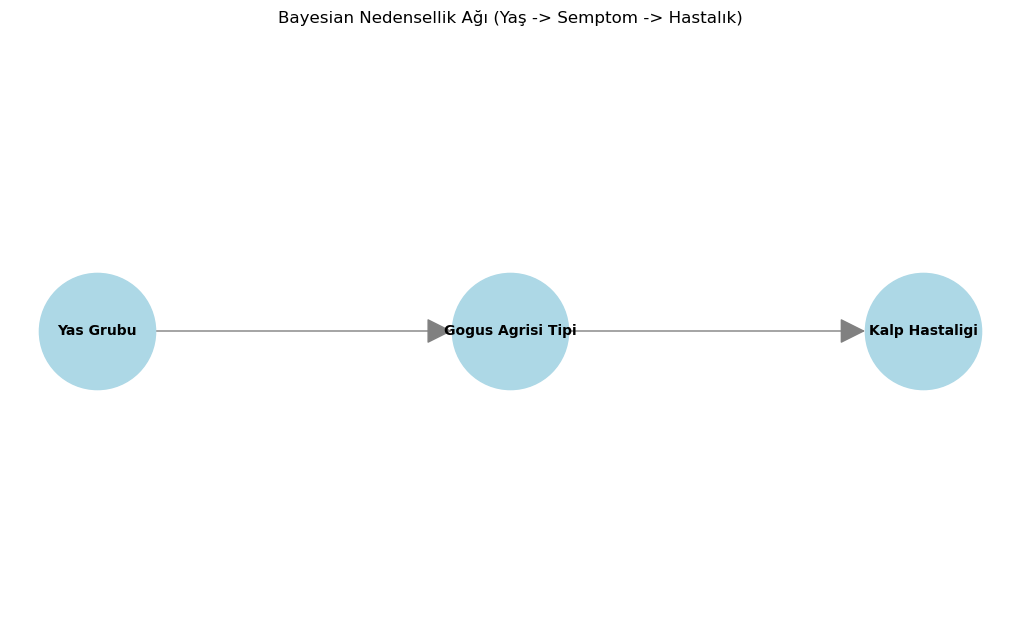


Göğüs Ağrısı Tipine Göre Hasta Olma Olasılıkları:


target_cat,Hasta,Saglikli
cp_cat,,
Tip 0 (Dusuk),0.245473,0.754527
Tip 1+ (Yuksek),0.765152,0.234848


In [16]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
G = nx.DiGraph()

G.add_edges_from([('Yas Grubu', 'Gogus Agrisi Tipi'), ('Gogus Agrisi Tipi', 'Kalp Hastaligi')])

pos = {'Yas Grubu': (0, 1), 'Gogus Agrisi Tipi': (1.5, 1), 'Kalp Hastaligi': (3, 1)} 

nx.draw(G, pos, with_labels=True, 
        node_size=7000, node_color="#add8e6", 
        font_size=10, font_weight="bold", arrowsize=40, edge_color="gray")

plt.title("Bayesian Nedensellik Ağı (Yaş -> Semptom -> Hastalık)")
plt.show()

cpt_cp_target = pd.crosstab(df_bayes['cp_cat'], df_bayes['target_cat'], normalize='index')
print("\nGöğüs Ağrısı Tipine Göre Hasta Olma Olasılıkları:")
display(cpt_cp_target)

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df_final = pd.read_csv("../data/heart.csv")

df_final = df_final.drop_duplicates()
print(f"Kopyalar temizlendi. Final Dosya Satır Sayısı: {df_final.shape[0]}")

cols_to_fix = ['chol', 'trestbps']
for col in cols_to_fix:
    df_final[col] = df_final[col].replace(0, np.nan)
    df_final[col] = df_final[col].fillna(df_final[col].median())


df_final = pd.get_dummies(df_final, columns=['cp', 'thal', 'slope'], drop_first=True, dtype=int)

df_final = df_final.replace({True: 1, False: 0})


scaler = MinMaxScaler()
cols_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_final[cols_to_scale] = scaler.fit_transform(df_final[cols_to_scale])

df_final.to_csv("../data/heart_FINAL_VERSION.csv", index=False)

print("\n✅ İŞLEM TAMAMLANDI!")
print("Dosya Adı: data/heart_FINAL_VERSION.csv")
print(f"Satır Sayısı: {df_final.shape[0]} (302 olmalı)")
display(df_final.head(3))

Kopyalar temizlendi. Final Dosya Satır Sayısı: 302

✅ İŞLEM TAMAMLANDI!
Dosya Adı: heart_FINAL_VERSION.csv
Satır Sayısı: 302 (302 olmalı)


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,slope_1,slope_2
0,0.479167,1,0.292453,0.196347,0,1,0.740458,0,0.161290,2,0,0,0,0,0,0,1,0,1
1,0.500000,1,0.433962,0.175799,1,0,0.641221,1,0.500000,0,0,0,0,0,0,0,1,0,0
2,0.854167,1,0.481132,0.109589,0,1,0.412214,1,0.419355,0,0,0,0,0,0,0,1,0,0
